In [1]:
import pandas as pd 
import numpy as np 

#ML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os
import random

       0    1    2    3    4    5    6    7    8    9  ...  984  985  seed  \
0    2.0  2.0  1.0  2.0  1.0  2.0  2.0  2.0  2.0  3.0  ...  NaN  NaN     0   
1    2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  ...  NaN  NaN     1   
2    3.0  3.0  2.0  2.0  2.0  3.0  2.0  2.0  2.0  3.0  ...  NaN  NaN     2   
3    2.0  2.0  1.0  1.0  1.0  1.0  1.0  2.0  2.0  2.0  ...  NaN  3.0     3   
4    2.0  2.0  2.0  2.0  2.0  1.0  2.0  2.0  2.0  3.0  ...  NaN  NaN     4   
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   ...   
795  3.0  NaN  3.0  NaN  NaN  3.0  NaN  2.0  1.0  NaN  ...  NaN  NaN   195   
796  2.0  NaN  3.0  3.0  NaN  3.0  2.0  NaN  NaN  NaN  ...  NaN  NaN   196   
797  NaN  NaN  NaN  NaN  NaN  2.0  NaN  1.0  NaN  3.0  ...  NaN  NaN   197   
798  NaN  3.0  3.0  NaN  NaN  3.0  3.0  3.0  3.0  NaN  ...  NaN  NaN   198   
799  NaN  0.0  NaN  3.0  3.0  2.0  NaN  3.0  NaN  NaN  ...  NaN  NaN   199   

     complex_param  simple_infection_ratio       EPH      corr 

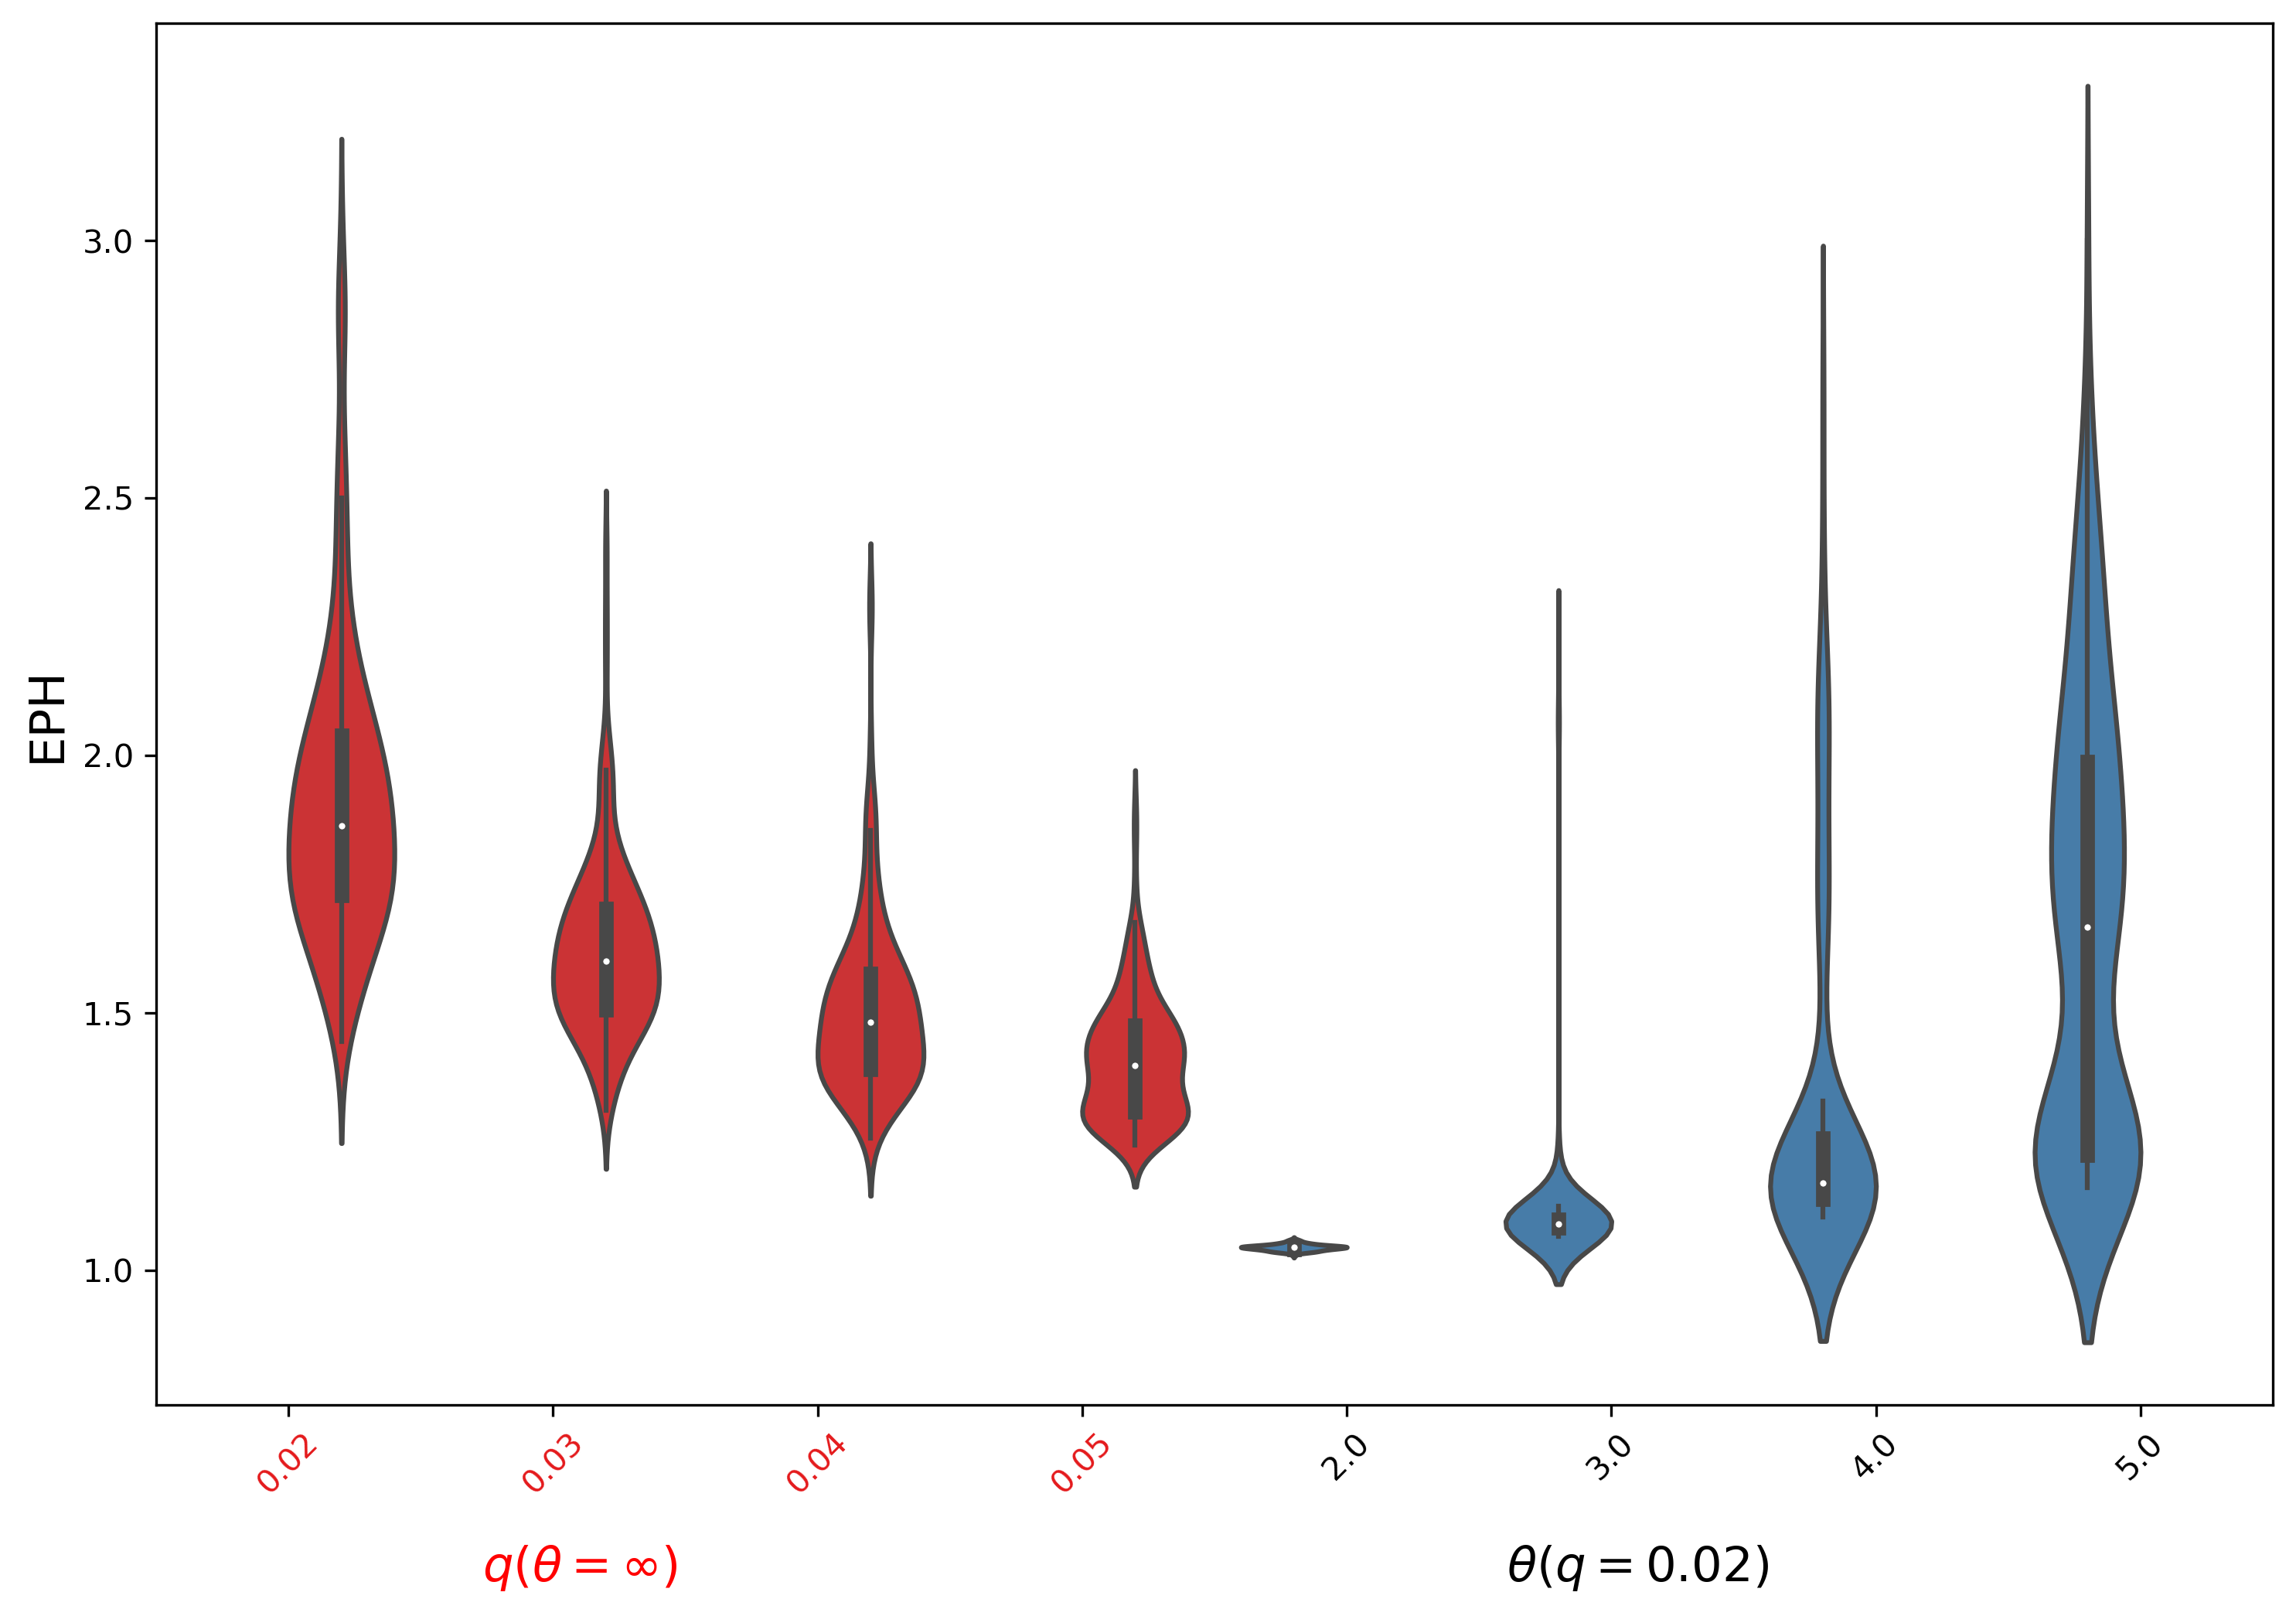

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def ensure_dir(file_path):
    """Create directory if it doesn't exist"""
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)

def plot_combined_violin_with_inset_boxplot(network_name):
    
    complex_thetas = [2, 3, 4, 5]
    simple_betas = [0.02, 0.03, 0.04,0.05]
    results_dir = '../result_3loopsstop_10%init_nodes-v3/unweighted/'
    complex_data = []
    simple_data = []
    
    for theta in complex_thetas:
#         random.seed(theta+1)
#         prob_complex = random.choice([-1,0.02])
        prob_complex = random.choice([0.02])
        file_path = os.path.join(results_dir, f'unweighted_complex_{network_name}_theta_{theta}_prob_{prob_complex}_EPH-v2.csv')
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df['network_type'] = 'Complex'
            df['x_column'] = theta
            complex_data.append(df)
    
    # Load simple contagion data
    for beta in simple_betas:
        file_path = os.path.join(results_dir, f'unweighted_simple_{network_name}_beta_{beta}_EPH-v2.csv')
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df['network_type'] = 'Simple'
            df['x_column'] = beta
            simple_data.append(df)
            
    complex_data = pd.concat(complex_data, ignore_index=True) if complex_data else pd.DataFrame()
    simple_data = pd.concat(simple_data, ignore_index=True) if simple_data else pd.DataFrame()
    

    # Combine both
    combined_data = pd.concat([complex_data, simple_data], axis=0)
    print(combined_data)

    # Set up the figure
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    
    # Plot the main violin plot with specified colors for simple and complex contagion
    sns.violinplot(
        x='x_column', y='EPH', hue='network_type', data=combined_data, ax=ax, 
        palette={'Complex': '#377eb8', 'Simple': '#e41a1c'}
    )
    ax.set_ylabel('EPH',fontsize=15)
    ax.set_title(f'Violin Plot of EPH for Different θ/β Values ({network_name} Network)')
    ax.set_title('')

    ax.tick_params(axis='x', rotation=45)
    ax.legend_.remove()  # Remove legend

    # Customize x-axis label to show "β" in red and "θ" in black
    ax.set_xlabel('')
    ax.text(
        0.7, -0.1, r'$\theta (q = 0.02)$', ha='center', va='top', transform=ax.transAxes,
        fontsize=15, color='black'
    )
    ax.text(
        0.2, -0.1, r'$q (\theta = ∞)$', ha='center', va='top', transform=ax.transAxes,
        fontsize=15, color='red'
    )

        # Customize the x-axis labels with colors for the main violin plot
    for label in ax.get_xticklabels():
        if label.get_text() in complex_data['x_column'].astype(str).unique():
            label.set_color('#377eb8')
        elif label.get_text() in simple_data['x_column'].astype(str).unique():
            label.set_color('#e41a1c')
    

#     # Create an inset axis for the box plot
#     inset_ax = fig.add_axes([0.14, 0.62, 0.5, 0.3])  # Adjust position and size as needed
#     sns.boxplot(
#         x='x_column', y='EPH', hue='network_type', data=combined_data, ax=inset_ax,
#         palette={'Complex': '#377eb8', 'Simple': '#e41a1c'}
#     )
#     inset_ax.set_xlabel('')
#     inset_ax.set_ylabel('')
#     inset_ax.set_title('')
#     inset_ax.legend_.remove()  # Remove legend from the inset for clarity
    
    # Customize the x-axis labels with colors for the inset box plot
#     for label in inset_ax.get_xticklabels():
#         if label.get_text() in complex_data['x_column'].astype(str).unique():
#             label.set_color('#377eb8')
#         elif label.get_text() in simple_data['x_column'].astype(str).unique():
#             label.set_color('#e41a1c')
    
    # Adjust layout and save the plot
    plt.tight_layout()
    base_path = "./res/"
    ensure_dir(f"{base_path}/temp.txt")
    plot_filename = f"{base_path}/violin_with_inset_boxplot_{network_name}.pdf"
    plt.savefig(plot_filename, format='pdf', dpi=1200, bbox_inches='tight')
    
    plt.show()

# Run the analysis for a set of networks
network_list = ['email_eu_modified']

# Create violin plots with an inset box plot for each network
for network_name in network_list:
    plot_combined_violin_with_inset_boxplot(network_name)


In [95]:
network_name = "email_eu_modified"
theta = 4
results_dir = '../results/unweighted/'
file_path = os.path.join(results_dir, f'unweighted_complex_{network_name}_theta_{theta}_prob_{0.02}_EPH.csv')
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    
df

,0,1,2,3,4,5,6,7,8,9,...,980,981,982,983,984,985,seed,complex_param,EPH,corr
0,3,3,2,3,2,2,3,3,3,4,...,NaN,3,4,NaN,NaN,NaN,0,4,1.341387,-0.708866
1,4,4,4,4,3,4,4,4,4,4,...,NaN,5,5,NaN,NaN,NaN,1,4,1.539215,-0.723410
2,5,4,4,4,4,4,5,4,4,5,...,NaN,6,6,NaN,NaN,NaN,2,4,1.489944,-0.678609
3,3,3,1,2,2,2,2,3,3,4,...,NaN,4,2,NaN,NaN,NaN,3,4,1.395723,-0.692276
4,3,3,2,2,2,3,3,3,2,3,...,NaN,4,4,NaN,NaN,NaN,4,4,1.383107,-0.733021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,4,3,2,3,2,3,3,4,3,4,...,NaN,4,4,NaN,NaN,NaN,195,4,1.373652,-0.740229
196,3,3,2,3,2,2,3,3,2,3,...,NaN,3,4,NaN,NaN,NaN,196,4,1.404337,-0.716587
197,4,4,4,4,3,3,4,3,4,4,...,NaN,5,5,NaN,NaN,NaN,197,4,1.455750,-0.725567
198,3,3,2,2,2,3,3,2,2,2,...,NaN,3,4,NaN,NaN,NaN,198,4,1.306977,-0.722658


In [96]:
df = df.drop(['seed','complex_param','EPH','corr'],axis=1)

In [97]:
np.mean(df.iloc[0].isna())

0.14705882352941177

In [93]:
network_name = "email_eu_modified"
beta = 0.0
file_path = os.path.join(results_dir, f'unweighted_simple_{network_name}_beta_{beta}_EPH.csv')
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
df = df.drop(['seed','simple_param','EPH','corr'],axis=1)

In [94]:
np.mean(df.iloc[0].isna())

0.14908722109533468